In [1]:
import pathlib
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import load_img
import seaborn as sns
import Augmentor
from tensorflow.python.keras.models import Sequential
import pydot


I0000 00:00:1783459617.740742 1618850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783459617.741059 1618850 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783459617.978784 1618850 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783459619.387003 1618850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

#### Global Variables

In [2]:
BATCH_SIZE = 32
IMAGE_SIZE = (180,180)
SEED = 42
AUTOTUNE = tf.data.experimental.AUTOTUNE

#### Check if the dataset exists, if not download it from S3 bucket.

In [3]:
from utils.dataset import check_dataset
check_dataset('dataset')

dataset_training_directory = pathlib.Path('dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train')
dataset_testing_directory = pathlib.Path('dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Test')

training_count = len(list(dataset_training_directory.glob('*/*.jpg')))
testing_count = len(list(dataset_testing_directory.glob('*/*.jpg')))
print("Training Data Count: " + str(training_count))
print("Testing Data Count: " + str(testing_count))

Dataset found.
Training Data Count: 2239
Testing Data Count: 118


#### Visualise the Data

Found 32128 files belonging to 9 classes.


E0000 00:00:1783459620.798973 1618850 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1783459620.799240 1619019 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783459620.821342 1618850 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


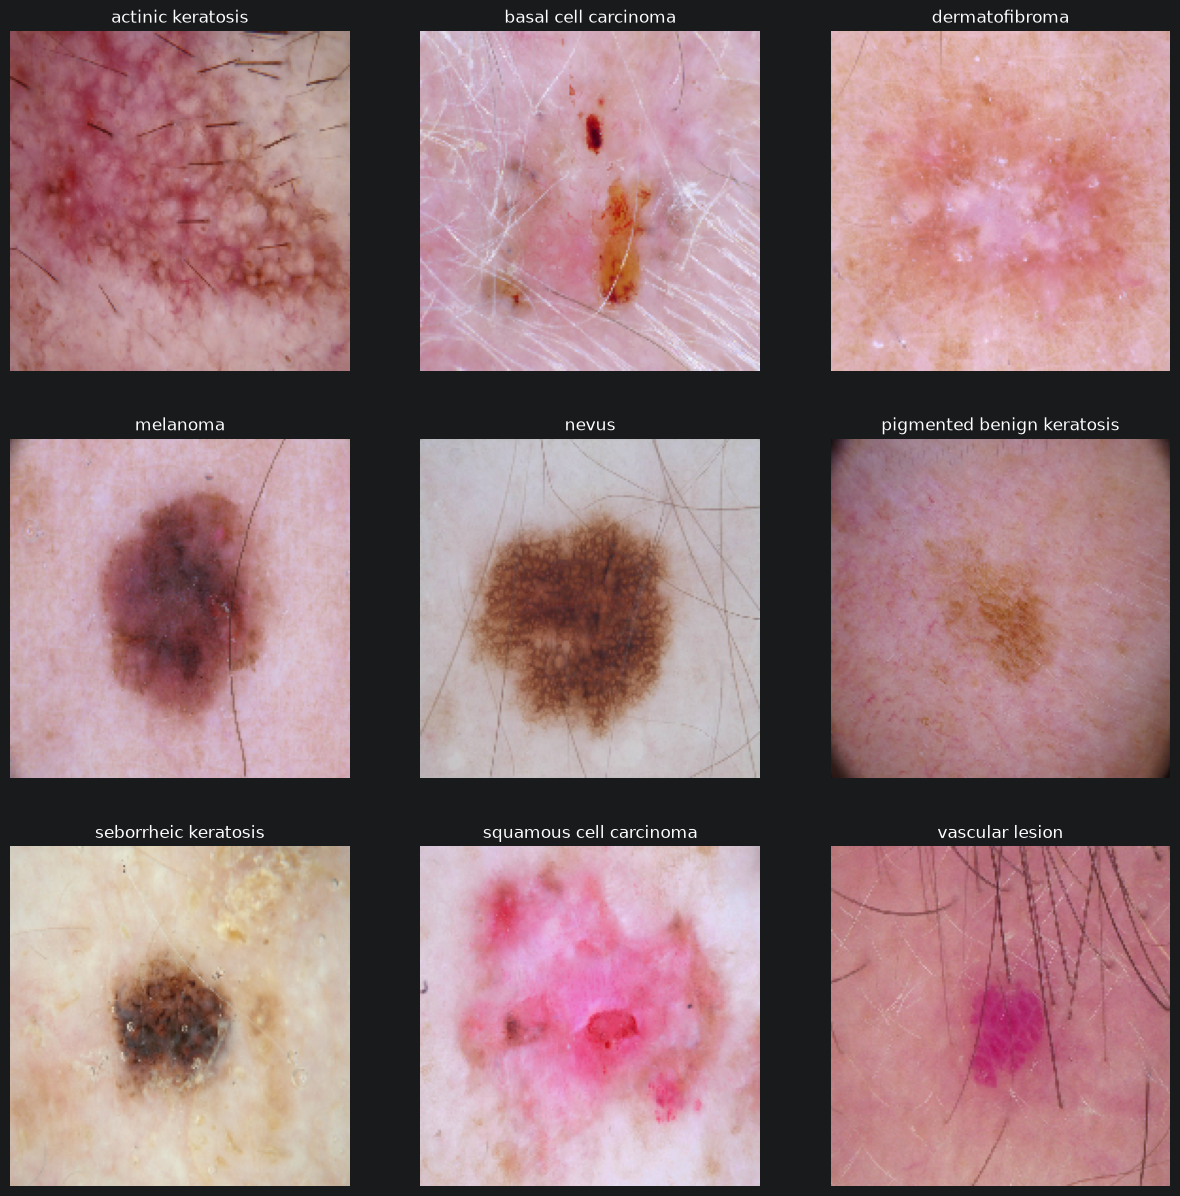

In [4]:
img_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_training_directory,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE,
    label_mode='categorical',
    seed=SEED
)

class_names = img_dataset.class_names

files_dir_dict = {}
for i in class_names:
    files_dir_dict[i] = list(map(lambda x:str(dataset_training_directory)+'/'+i+'/'+x,os.listdir(str(dataset_training_directory)+'/'+i)))

plt.figure(figsize=(15,15))
index = 0
for c in class_names:
    path_list = files_dir_dict[c][:1]
    index += 1
    plt.subplot(3,3,index)
    plt.imshow(load_img(path_list[0],target_size=(180,180)))
    plt.title(c)
    plt.axis("off")

#### Data Distribution Visualization

This section visualises the distribution of images across different classes in the training dataset. The `class_distribution_count` function counts the number of images in each subdirectory of the training dataset, and the result is stored in a DataFrame (`df`). A bar plot is then created using Seaborn to display the number of images per class.


In [5]:
def class_distribution_count(directory):

    count= []
    for path in pathlib.Path(directory).iterdir():
        if path.is_dir():
            count.append(len([name for name in os.listdir(path)
                               if os.path.isfile(os.path.join(path, name))]))

    sub_directory = [name for name in os.listdir(directory)
                    if os.path.isdir(os.path.join(directory, name))]

    return pd.DataFrame(list(zip(sub_directory,count)),columns =['Class', 'No. of Image'])

df = class_distribution_count(dataset_training_directory)
df

,Class,No. of Image
0,actinic keratosis,114
1,basal cell carcinoma,376
2,dermatofibroma,95
3,melanoma,438
4,nevus,357
5,pigmented benign keratosis,462
6,seborrheic keratosis,77
7,squamous cell carcinoma,181
8,vascular lesion,139


<Axes: xlabel='No. of Image', ylabel='Class'>

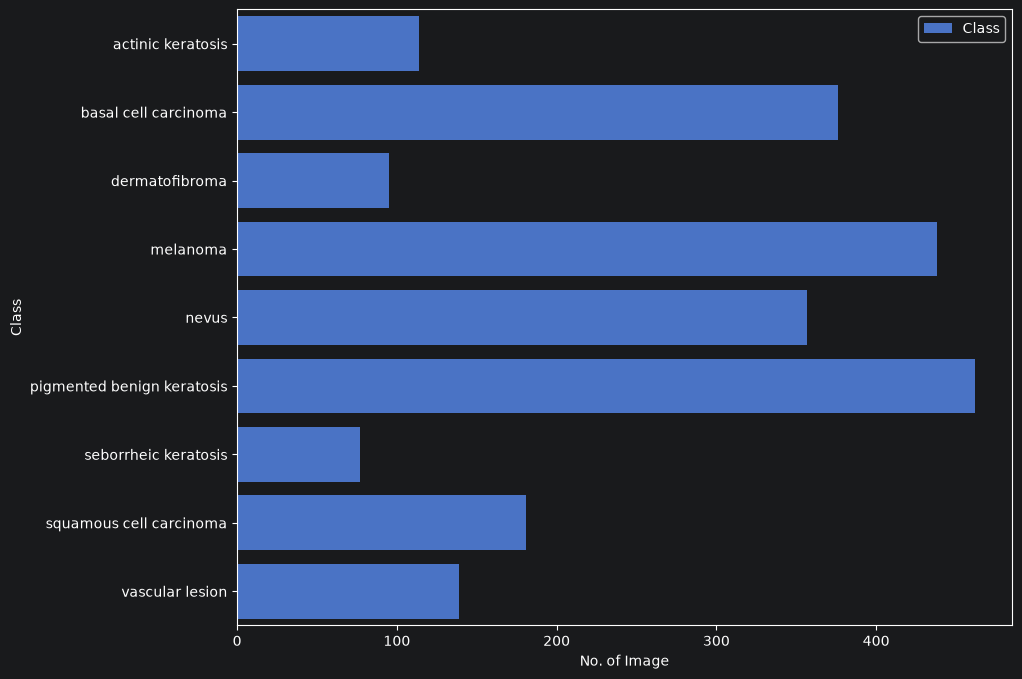

In [6]:
plt.figure(figsize=(10, 8))
sns.barplot(x="No. of Image", y="Class", data=df,label = "Class")

In [7]:
path_to_training_dataset="dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/"

for i in class_names:
    p = Augmentor.Pipeline(path_to_training_dataset + i)
    p.rotate(probability=0.7, max_left_rotation=10, max_right_rotation=10)
    p.sample(500)

Initialised with 114 image(s) found.
Output directory set to dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/actinic keratosis/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7EFB41CC9310>: 100%|██████████| 500/500 [00:00<00:00, 867.29 Samples/s]                  


Initialised with 376 image(s) found.
Output directory set to dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/basal cell carcinoma/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7EFB40139430>: 100%|██████████| 500/500 [00:00<00:00, 871.05 Samples/s]                  


Initialised with 95 image(s) found.
Output directory set to dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/dermatofibroma/output.

...

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1024x768 at 0x7EFB205202C0>: 100%|██████████| 500/500 [00:01<00:00, 412.53 Samples/s]


Initialised with 181 image(s) found.
Output directory set to dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/squamous cell carcinoma/output.

Processing <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x450 at 0x7EFB205A5160>: 100%|██████████| 500/500 [00:00<00:00, 898.00 Samples/s]


Initialised with 139 image(s) found.
Output directory set to dataset/Skin cancer ISIC The International Skin Imaging Collaboration/Train/vascular lesion/output.

Processing <PIL.Image.Image image mode=RGB size=600x450 at 0x7EFB203FCBF0>: 100%|██████████| 500/500 [00:00<00:00, 904.75 Samples/s]                  


In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(dataset_training_directory, batch_size=32,
                                                               image_size=(180,180), label_mode='categorical',
                                                               seed=123,subset="training",
                                                               validation_split=0.2)
val_ds =tf.keras.preprocessing.image_dataset_from_directory(dataset_training_directory,batch_size=32,
                                                            image_size=(180,180), label_mode='categorical',
                                                            seed=123,subset="validation",
                                                            validation_split=0.2)
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 36628 files belonging to 9 classes.
Using 29303 files for training.
Found 36628 files belonging to 9 classes.
Using 7325 files for validation.


#### Setting up CNN Model Architecture

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,648,137 (25.36 MB)

 Trainable params: 6,648,137 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

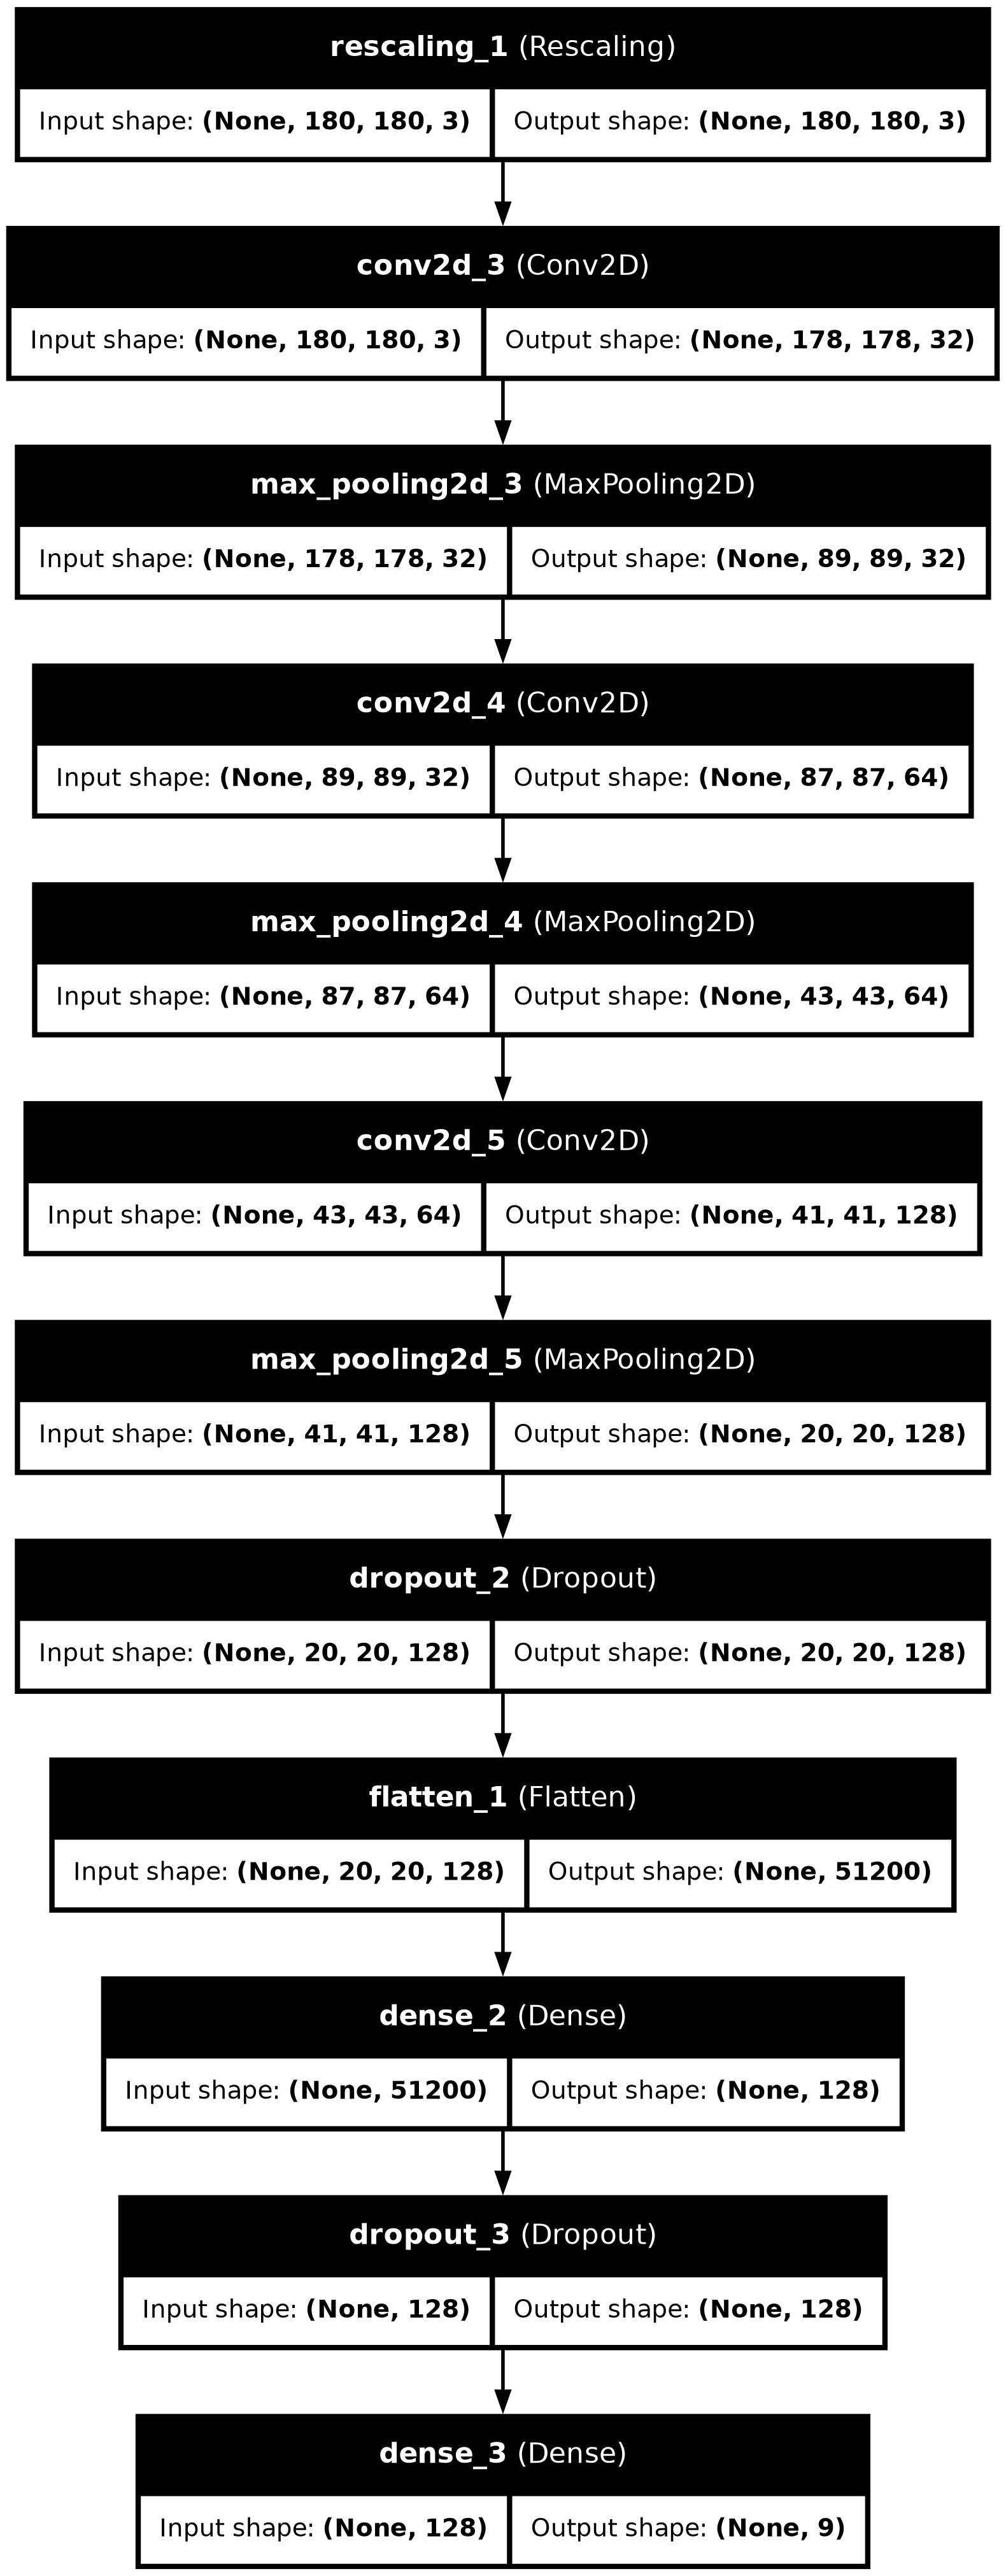

In [10]:
model = tf.keras.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Rescaling(1./255),
    #1
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),
    #2
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),
    #3
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),

    layers.Dropout(0.5),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.25),
    layers.Dense(len(class_names), activation='softmax')
])


model.summary()
from tensorflow.keras.utils import plot_model
plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)